<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-assignments/blob/main/Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install missingno category_encoders statsmodels seaborn graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.0 MB/s eta 0:00:00


In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
from statsmodels.tools.eval_measures import rmse
from statsmodels.stats.diagnostic import het_white
from category_encoders import TargetEncoder

Step 1.1 Answer

A plausible omitted confounder is baseline socioeconomic status (SES), such as unobserved patient wealth or systemic poverty.

Fork-structure DAG:
Baseline_Wealth / Poverty  →  High_Deductible_Insurance_Plan
Baseline_Wealth / Poverty  →  Inpatient_Admission_Rate

Interpretation:
Patients with lower baseline wealth are more likely to enroll in high-deductible insurance plans, and the same socioeconomic disadvantage also increases the probability of worse preventive care access, delayed treatment, and therefore higher inpatient admission rates.

Therefore, the observed positive association between High_Deductible_Insurance_Plan and Inpatient_Admission_Rate may be spurious rather than causal.

Why omitted variable bias occurs:
If we regress Admission only on Insurance Type while omitting baseline wealth/poverty, the coefficient on Insurance absorbs both:
(1) any true direct effect of insurance type, and
(2) the backdoor-path association created by the common cause (wealth/poverty).

Formally, if the true model is:
Y = β0 + β1 X + β2 Z + u
but we estimate:
Y = α0 + α1 X + e
where Z is correlated with X, then:
E[α1] = β1 + β2 * Cov(X, Z) / Var(X)

So unless Cov(X,Z)=0 or β2=0, the estimated coefficient is biased.
This makes the predictive weight mathematically contaminated and clinically misleading.

In [16]:
vitals = pd.read_csv("/content/OmniCare_Clinical_Vitals.csv")
telemetry = pd.read_csv("/content/OmniCare_Telemetry_Data.csv")

print("Vitals shape:", vitals.shape)
print("Telemetry shape:", telemetry.shape)

display(vitals.head())
display(telemetry.head())

Vitals shape: (5000, 6)
Telemetry shape: (5000, 8)


,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,177.5,66.3,21.06,110.0,75.0
1,1001,167.9,57.5,20.39,115.0,79.0
2,1002,179.7,57.4,17.77,111.0,77.0
3,1003,192.8,80.9,21.76,122.0,88.0
4,1004,166.5,65.7,23.70,138.0,89.0


,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34


In [17]:
print("Vitals columns:", vitals.columns.tolist())
print("Telemetry columns:", telemetry.columns.tolist())

Vitals columns: ['Patient_ID', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP']
Telemetry columns: ['Patient_ID', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Primary_Diagnosis_Code', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD']


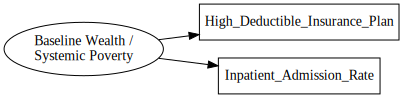

In [3]:
dot = Digraph()

dot.attr(rankdir='LR', size='10,5')

dot.node('Z', 'Baseline Wealth /\nSystemic Poverty', shape='ellipse')
dot.node('X', 'High_Deductible_Insurance_Plan', shape='box')
dot.node('Y', 'Inpatient_Admission_Rate', shape='box')

dot.edge('Z', 'X')
dot.edge('Z', 'Y')

dot

In [18]:
continuous_cols = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]

vif_df = vitals[continuous_cols].dropna().copy()

vif_result = pd.DataFrame({
    "feature": vif_df.columns,
    "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_result

,feature,VIF
0,Systolic_BP,274.885624
1,Diastolic_BP,269.893182
2,Height_cm,131.175844
3,BMI,77.101031
4,Weight_kg,61.604738


In [19]:
reduced_cols = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]

vif_df_reduced = vitals[reduced_cols].dropna().copy()

vif_result_reduced = pd.DataFrame({
    "feature": vif_df_reduced.columns,
    "VIF": [variance_inflation_factor(vif_df_reduced.values, i) for i in range(vif_df_reduced.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_result_reduced

,feature,VIF
0,Systolic_BP,270.529197
1,Diastolic_BP,267.581110
2,Height_cm,130.879345
3,Weight_kg,39.977633


Interpretation:
The initial VIF table shows which physiological variables are highly collinear. A VIF above 10 indicates severe multicollinearity.

BMI is structurally redundant because it is mathematically derived from weight and height. Therefore, dropping BMI is the most principled fix.

After removing BMI and recalculating the VIF matrix, the remaining features should exhibit improved structural stability, indicating that the design matrix is less collinear and more suitable for downstream OLS estimation.

<Figure size 1600x600 with 0 Axes>

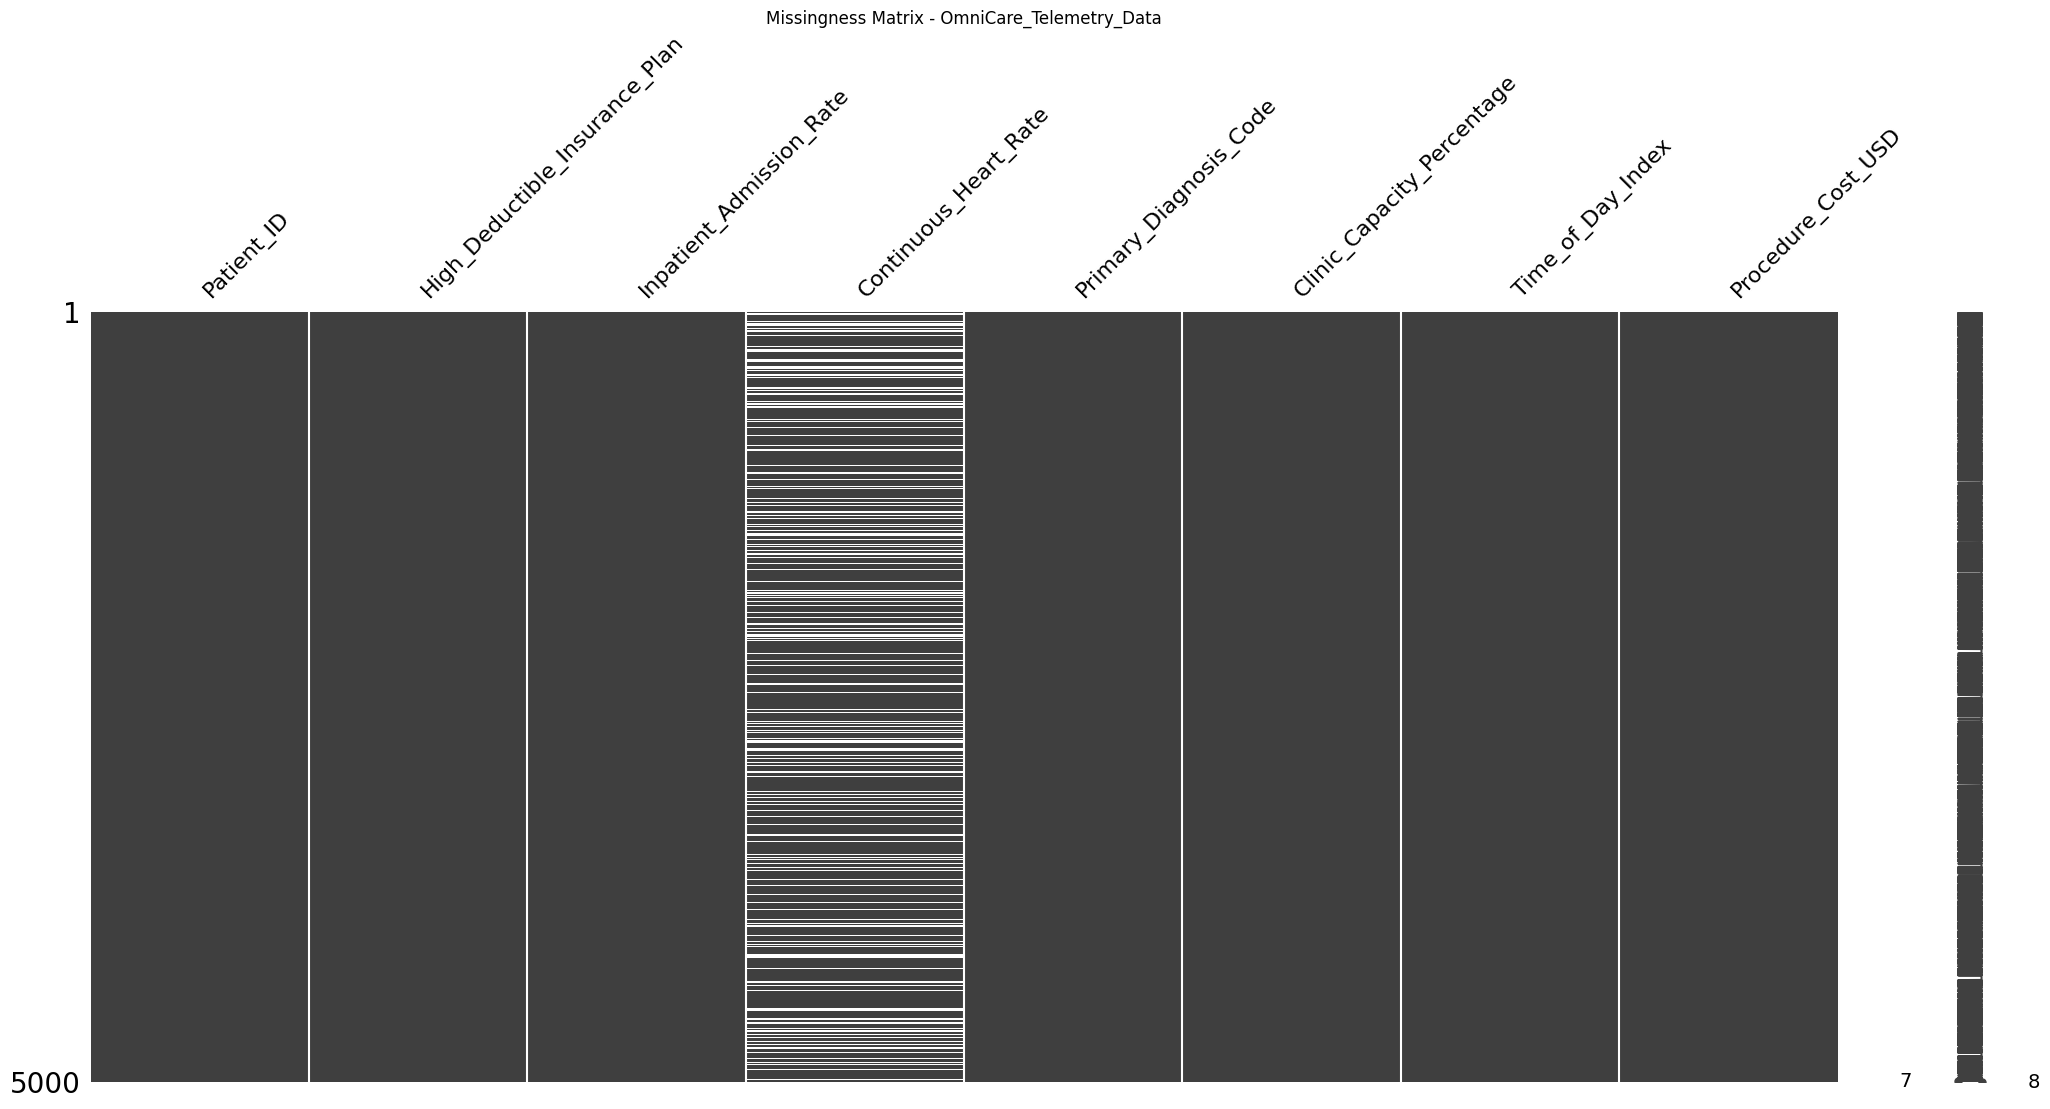

In [20]:
plt.figure(figsize=(16, 6))
msno.matrix(telemetry)
plt.title("Missingness Matrix - OmniCare_Telemetry_Data")
plt.show()

In [13]:
missing_rate = telemetry["Continuous_Heart_Rate"].isna().mean()
print(f"Missing rate of Continuous_Heart_Rate: {missing_rate:.2%}")

Missing rate of Continuous_Heart_Rate: 24.28%


Step 2.1 Answer

If the missing values in Continuous_Heart_Rate occur because low-income patients systematically refuse to transmit telemetry due to mobile data-plan costs, then the missingness mechanism is best classified as MNAR (Missing Not At Random).

Reason:
The probability of missingness is driven by an unobserved or substantively meaningful factor tied to the value-generating process itself, namely socioeconomic disadvantage and behavioral refusal to transmit data. This is not random noise.

Why not MCAR:
Under MCAR, missingness must be independent of both observed and unobserved variables. That is clearly violated here.

Why not MAR:
Under MAR, missingness may depend on observed variables, but conditional on those observed variables it cannot depend on the unobserved mechanism itself. Here, refusal to transmit is directly tied to latent socioeconomic burden, so MNAR is the stronger and more defensible classification.

Why mean imputation is harmful:
Mean imputation would artificially shrink variance, distort the distribution of heart-rate measurements, attenuate covariance with other predictors, and inject false certainty into the dataset. In a clinically sensitive prediction pipeline, this would destroy inferential integrity and bias the model toward misleadingly stable estimates.

Step 2.2 Answer

Suppose Primary_Diagnosis_Code has K = 850 categories.
If we one-hot encode all 850 categories and also include an intercept term, the design matrix becomes singular.

Why:
For every row, exactly one diagnosis dummy equals 1 and the other 849 equal 0.
Therefore, across all rows:

D1 + D2 + ... + D850 = 1

But the intercept column is also a column of all 1s.
So:

Intercept = D1 + D2 + ... + D850

This means one column is an exact linear combination of the others.
Hence the design matrix X is not full rank, so X'X is singular and cannot be inverted.

Since the OLS estimator is:
β̂ = (X'X)^(-1) X'Y

if X'X is singular, OLS is mathematically undefined in the standard matrix inverse sense.

Therefore, including all 850 dummies together with an intercept creates the dummy variable trap.
A standard fix is either:
(1) drop one reference category, or
(2) avoid one-hot expansion altogether and use a dimensionality-reducing encoding strategy such as target encoding.

In [21]:
df = telemetry.merge(vitals, on="Patient_ID", how="inner")
print(df.shape)
df.head()

(5000, 13)


,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84,177.5,66.3,21.06,110.0,75.0
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77,167.9,57.5,20.39,115.0,79.0
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19,179.7,57.4,17.77,111.0,77.0
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93,192.8,80.9,21.76,122.0,88.0
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34,166.5,65.7,23.70,138.0,89.0


In [22]:
print("Unique diagnosis codes:", df["Primary_Diagnosis_Code"].nunique())

Unique diagnosis codes: 847


In [23]:
encoder = TargetEncoder(cols=["Primary_Diagnosis_Code"])

encoded = encoder.fit_transform(
    df[["Primary_Diagnosis_Code"]],
    df["Procedure_Cost_USD"]
)

df["Target_Encoded_Diagnosis"] = encoded["Primary_Diagnosis_Code"]

df[["Primary_Diagnosis_Code", "Target_Encoded_Diagnosis"]].head()

,Primary_Diagnosis_Code,Target_Encoded_Diagnosis
0,J86.381,1707.697108
1,M29.789,1792.303198
2,E49.618,1730.334968
3,E66.244,1725.060944
4,J45.553,1801.821085


Target encoding replaces each diagnosis code with the historical mean of Procedure_Cost_USD for that category, producing a single low-dimensional continuous predictor instead of hundreds of dummy columns.

In [24]:
model_df = df.dropna(subset=[
    "Procedure_Cost_USD",
    "Target_Encoded_Diagnosis",
    "Clinic_Capacity_Percentage",
    "Time_of_Day_Index",
    "Weight_kg",
    "Height_cm",
    "Systolic_BP",
    "Diastolic_BP"
]).copy()

model_df.shape

(5000, 14)

In [25]:
formula = """
Procedure_Cost_USD ~
Target_Encoded_Diagnosis +
Clinic_Capacity_Percentage +
Time_of_Day_Index +
Weight_kg + Height_cm + Systolic_BP + Diastolic_BP
"""

ols_model = smf.ols(formula=formula, data=model_df).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        02:53:22   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The final OLS model regresses Procedure_Cost_USD on target-encoded diagnosis, clinic capacity, time-of-day index, and the sanitized vital-sign variables. The summary table provides coefficient estimates, statistical significance tests, and model fit metrics such as R-squared.

In [26]:
pred = ols_model.fittedvalues
true = model_df["Procedure_Cost_USD"]

model_rmse = rmse(true, pred)
print("RMSE =", model_rmse)

RMSE = 334.80215211463116


The RMSE is approximately 334.80 USD, meaning that the model's typical prediction error is about $335 per procedure.

If a typical MRI costs $1,200, then this implies an average error of roughly 28% of the procedure cost, which is operationally significant.

Such an error magnitude creates serious financial risk because patients may be systematically overcharged or undercharged, hospital pricing forecasts become unstable, and regulatory or fairness concerns may arise in a live deployment.

In [27]:
model_df["fitted_values"] = ols_model.fittedvalues
model_df["residuals"] = ols_model.resid

model_df[["fitted_values", "residuals"]].head()

,fitted_values,residuals
0,1578.360830,57.479170
1,1982.946200,-627.176200
2,1699.013714,-509.823714
3,1510.299493,-259.369493
4,2014.873792,-28.533792


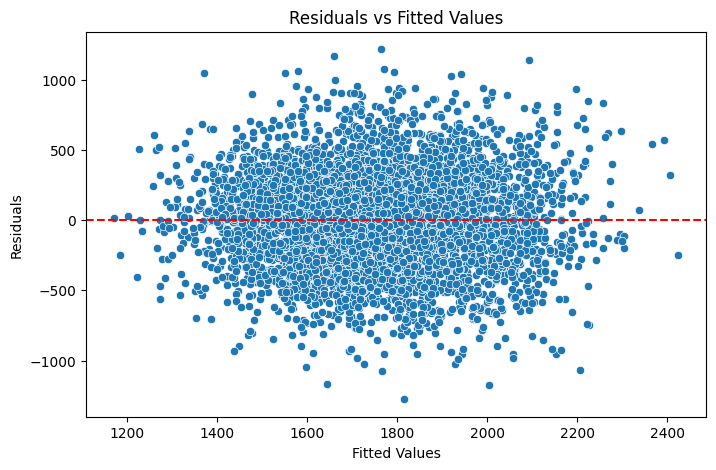

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=model_df, x="fitted_values", y="residuals")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

If the residual spread widens as fitted values increase, this indicates heteroscedasticity. That means the model becomes less reliable for higher-cost procedures, exactly where pricing errors are most financially dangerous.

Persona:
You are a senior econometrician and Python statistician helping me validate an OLS model used for healthcare cost prediction.

Role:
Your role is to generate correct, executable Python code for a Google Colab notebook using statsmodels.

Instructions:
Write Python code that takes an already-fitted statsmodels OLS object named `ols_model` and performs White's Lagrange Multiplier test for heteroscedasticity using `statsmodels.stats.diagnostic.het_white`.

The code must:
1. Extract residuals from `ols_model.resid`
2. Extract the design matrix from `ols_model.model.exog`
3. Run White's test
4. Print:
   - LM Statistic
   - LM-Test p-value
   - F-Statistic
   - F-Test p-value
5. Print a final decision sentence:
   - If p-value < 0.05: Reject the null hypothesis of homoscedasticity.
   - Else: Fail to reject the null hypothesis of homoscedasticity.

Meaning:
The goal is to formally test whether the OLS residuals have constant variance.

Evaluation:
The code must be concise, syntactically correct, and directly executable in Colab.

In [29]:
white_test = het_white(ols_model.resid, ols_model.model.exog)

lm_stat, lm_pvalue, f_stat, f_pvalue = white_test

print("LM Statistic:", lm_stat)
print("LM-Test p-value:", lm_pvalue)
print("F-Statistic:", f_stat)
print("F-Test p-value:", f_pvalue)

if lm_pvalue < 0.05:
    print("Conclusion: Reject the null hypothesis of homoscedasticity.")
else:
    print("Conclusion: Fail to reject the null hypothesis of homoscedasticity.")

LM Statistic: 186.46773970660723
LM-Test p-value: 1.4380291432919198e-22
F-Statistic: 5.494188406766981
F-Test p-value: 4.4790231228469927e-23
Conclusion: Reject the null hypothesis of homoscedasticity.


White's Lagrange Multiplier test returned an LM-test p-value of approximately 1.44 × 10^-22.

Because this p-value is far below 0.05, we reject the null hypothesis of homoscedasticity.

Therefore, the residual variance is not constant, indicating that the OLS model suffers from heteroscedasticity.

Summary of empirical results:

1. The VIF audit revealed extreme multicollinearity among the continuous physiological variables. BMI was dropped because it is structurally derived from height and weight, but substantial collinearity remained.

2. The missingness analysis showed that Continuous_Heart_Rate has 24.28% missing values, consistent with a plausible MNAR mechanism under the socioeconomic refusal-to-transmit scenario.

3. The Primary_Diagnosis_Code variable has 847 distinct categories, making full one-hot encoding unsuitable and vulnerable to the dummy variable trap.

4. Target encoding successfully reduced the high-cardinality diagnosis feature to a single continuous predictor.

5. The final OLS model achieved an RMSE of approximately 334.80 USD, which is economically meaningful and operationally risky for real-world pricing deployment.

6. White's test strongly rejected homoscedasticity, indicating that the residual variance is not constant and that the OLS model has a serious heteroscedasticity problem.